In [1]:
pip install ydata_profiling

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from ydata_profiling import ProfileReport
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
import warnings
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import pickle
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv("C:/Users/Dell/OneDrive/Desktop/loan_approved.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
df.isnull().sum()

Loan_ID                    0
Gender                    13
Married                    3
Dependents                15
Education                  0
Self_Employed             32
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                22
Loan_Amount_Term          14
Credit_History            50
Property_Area              0
Loan_Status (Approved)     0
dtype: int64

In [7]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [8]:
df.describe(include ='O')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status (Approved)
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [9]:
df.loc[df['Gender'].isnull(),'Gender']="Male"  # We have imputed the null values with the Male

In [10]:
df.Gender.isnull().sum()

0

In [11]:
df.loc[df['Credit_History'].isnull(),'Credit_History']=0.0 # We have imputed the null values with the 0

In [12]:
df.Credit_History.isnull().sum()

0

In [13]:
df.loc[df['LoanAmount'].isnull(),'LoanAmount']=df['LoanAmount'].median() # We have imputed the null values with the median

In [14]:
df.LoanAmount.isnull().sum()

0

In [15]:
df.loc[df['Married'].isnull(),'Married']="Yes"

In [16]:
df.loc[df['Self_Employed'].isnull(),'Self_Employed']='No'

In [17]:
df.loc[df['Loan_Amount_Term'].isnull(),'Loan_Amount_Term']=360.0

In [18]:
df.loc[df['Dependents'].isnull(),'Dependents']='0'

In [19]:
df.isnull().sum()

Loan_ID                   0
Gender                    0
Married                   0
Dependents                0
Education                 0
Self_Employed             0
ApplicantIncome           0
CoapplicantIncome         0
LoanAmount                0
Loan_Amount_Term          0
Credit_History            0
Property_Area             0
Loan_Status (Approved)    0
dtype: int64

In [20]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status (Approved)'],
      dtype='object')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Loan_ID                 614 non-null    object 
 1   Gender                  614 non-null    object 
 2   Married                 614 non-null    object 
 3   Dependents              614 non-null    object 
 4   Education               614 non-null    object 
 5   Self_Employed           614 non-null    object 
 6   ApplicantIncome         614 non-null    int64  
 7   CoapplicantIncome       614 non-null    float64
 8   LoanAmount              614 non-null    float64
 9   Loan_Amount_Term        614 non-null    float64
 10  Credit_History          614 non-null    float64
 11  Property_Area           614 non-null    object 
 12  Loan_Status (Approved)  614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


# Visualizing the outliers :

<Axes: xlabel='LoanAmount'>

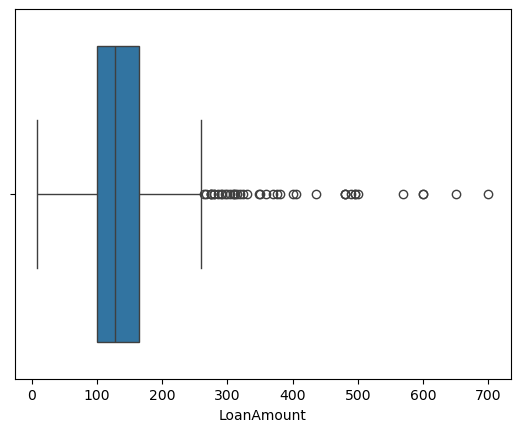

In [23]:
sns.boxplot(x=df.LoanAmount ,orient='h')

In [24]:
from scipy.stats.mstats import winsorize

# Specify the percentage of data to be trimmed from both ends
trim_percentage = 0.05

# Winsorize the specified column
df['ApplicantIncome'] = winsorize(df['ApplicantIncome'], limits=trim_percentage)

<Axes: xlabel='ApplicantIncome'>

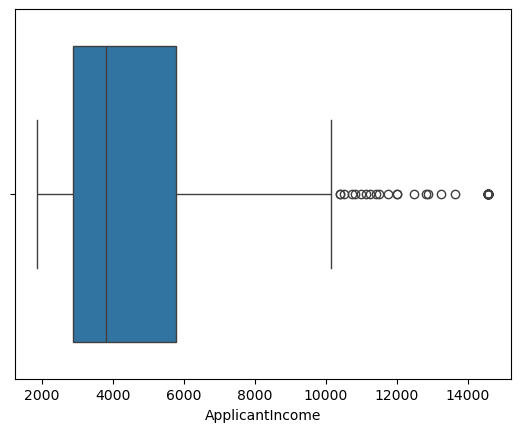

In [25]:
sns.boxplot(x=df.ApplicantIncome ,orient='h')

In [26]:
# Calculate quartiles
Q1 = df['LoanAmount'].quantile(0.25)
Q3 = df['LoanAmount'].quantile(0.75)

In [27]:
# Calculate IQR
IQR = Q3 - Q1
IQR

64.5

In [28]:
# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [29]:
print(lower_bound)
print(upper_bound)

3.5
261.5


In [30]:
# Remove outliers
df = df[(df['LoanAmount'] >= lower_bound) & (df['LoanAmount'] <= upper_bound)]

<Axes: xlabel='LoanAmount'>

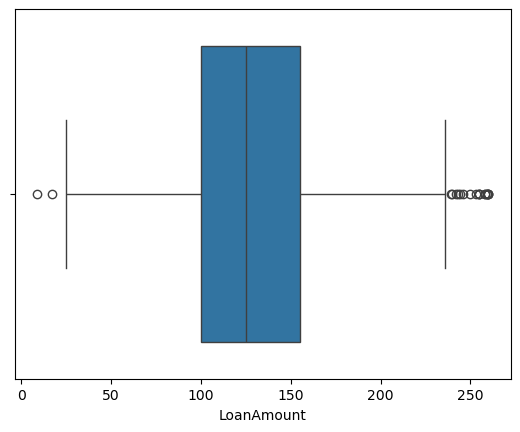

In [31]:
sns.boxplot(x=df.LoanAmount ,orient='h')

In [32]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status (Approved)'],
      dtype='object')

In [33]:
df['Married'].value_counts()


Married
Yes    370
No     203
Name: count, dtype: int64

In [34]:
df['Dependents'].value_counts()

Dependents
0     345
2      96
1      92
3+     40
Name: count, dtype: int64

In [35]:
df['Loan_Status (Approved)'].value_counts()

Loan_Status (Approved)
Y    397
N    176
Name: count, dtype: int64

In [36]:
df['Property_Area'].value_counts()

Property_Area
Semiurban    220
Urban        188
Rural        165
Name: count, dtype: int64

In [37]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Using Label encoding :

In [38]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

# Fit and transform the 'matchType' column to obtain label-encoded values
df['Married'] = encoder.fit_transform(df['Married'])

# Display the result
print(df[['Married']])

     Married
0          0
1          1
2          1
3          1
4          0
..       ...
609        0
610        1
611        1
612        1
613        0

[573 rows x 1 columns]


In [39]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

# Fit and transform the 'matchType' column to obtain label-encoded values
df['Loan_Status (Approved)'] = encoder.fit_transform(df['Loan_Status (Approved)'])

# Display the result
print(df[['Loan_Status (Approved)']])

     Loan_Status (Approved)
0                         1
1                         0
2                         1
3                         1
4                         1
..                      ...
609                       1
610                       1
611                       1
612                       1
613                       0

[573 rows x 1 columns]


# Using Ordinal Encoder :

In [40]:
df.Education.value_counts()

Education
Graduate        440
Not Graduate    133
Name: count, dtype: int64

In [41]:
Education_enc=OrdinalEncoder(categories=[['Graduate', 'Not Graduate']])

In [42]:
df['Education'] = encoder.fit_transform(df[['Education']])

In [43]:
df.Education.value_counts()

Education
0    440
1    133
Name: count, dtype: int64

In [44]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status (Approved)'],
      dtype='object')

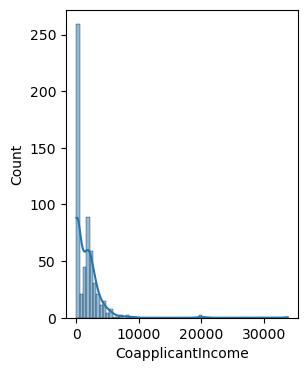

In [45]:
plt.figure(figsize=(3,4))
sns.histplot(x=df['CoapplicantIncome'], kde= True) # left screwed
plt.show()

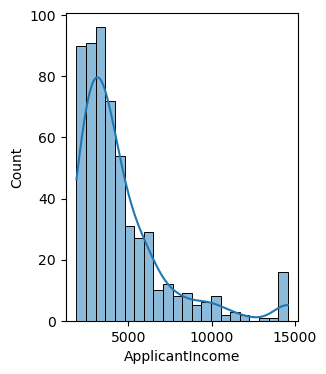

In [46]:
plt.figure(figsize=(3,4))
sns.histplot(x=df['ApplicantIncome'], kde= True) # left screwed
plt.show()

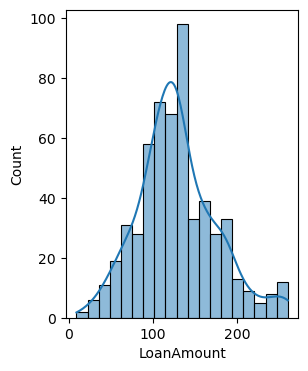

In [47]:
plt.figure(figsize=(3,4))
sns.histplot(x=df['LoanAmount'], kde= True) # left screwed
plt.show()

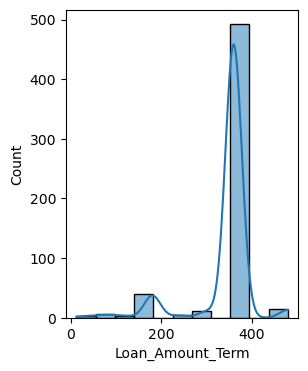

In [48]:
plt.figure(figsize=(3,4))
sns.histplot(x=df['Loan_Amount_Term'], kde= True) # right screwed
plt.show()

In [49]:
# Using Log transformation :

In [50]:
df['CoapplicantIncome']=np.log(df['CoapplicantIncome'])


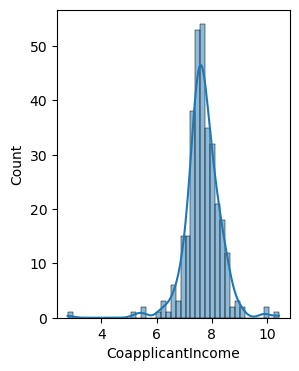

In [51]:
plt.figure(figsize=(3,4))
sns.histplot(x=df['CoapplicantIncome'], kde= True) # Target columns
plt.show()

In [52]:
# Using Exponential Transformers :

In [53]:
df['ApplicantIncome_exponential']=df.ApplicantIncome**(1/1.2)

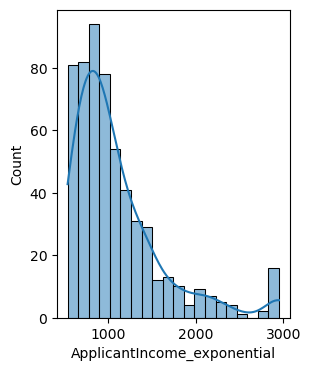

In [54]:
plt.figure(figsize=(3,4))
sns.histplot(x=df['ApplicantIncome_exponential'], kde= True)
plt.show()

In [55]:
# Using Box Cox Transformation :

In [56]:
from scipy.stats import boxcox
transformed_data, lambda_value = boxcox(df['Loan_Amount_Term'])


In [57]:
print("Transformed data:", transformed_data)

Transformed data: [1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 6.25636008e+05 1.72400389e+07 5.06987490e+06 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 1.72400389e+07 1.72400389e+07 1.72400389e+07
 1.72400389e+07 2.12746722e+06 1.72400389e+07 1.72400389e+07
 1.72400389e+07 2.12746722e+06 7.72048881e+04 1.72400389e+07
 1.724

In [58]:
# Using Square Root Transformation :

In [59]:
df['LoanAmount']=df.LoanAmount**(1/2) # this column is right scre

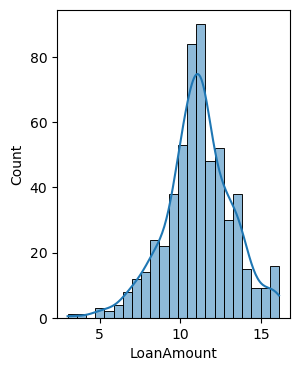

In [60]:
plt.figure(figsize=(3,4))
sns.histplot(x=df['LoanAmount'], kde= True)
plt.show()